In [1]:
import pandas as pd
from collections import defaultdict, Counter
import glob
import json
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import re

In [2]:
import re
import unicodedata

SPECIAL_CHARS = re.compile(r"['|?!<:;]")

def normalize(s: str) -> str:
    # 1. Unicode normalization (NFC handles macOS NFD filenames, etc.)
    s = unicodedata.normalize("NFC", s)
    # 2. Strip whitespace
    s = s.strip()
    # 3. Case-fold for unicode-aware case-insensitive matching
    s = s.casefold()
    # 4. Replace special characters with underscores
    s = SPECIAL_CHARS.sub("_", s)
    return s

In [3]:
human_dict = {
    "document_id": [],
    "sentence_id": [],
    "label": [],
    "score": []
}
for json_path in tqdm(glob.glob("./predict-286-gutenberg_de/*.json")):
    #document_id = normalize(json_path.split("/")[-1].replace("-result.json", ".txt"))
    document_id = json_path.split("/")[-1].replace("-result.json", ".txt")
    try:
        with open(json_path, "r") as f:
            predictions = json.load(f)
        for sentence_id, prediction in enumerate(predictions):
            human_dict["document_id"].append(document_id)
            human_dict["sentence_id"].append(sentence_id)
            human_dict["label"].append(prediction["label"])
            human_dict["score"].append(prediction["score"])
    except: 
        print(json_path)
human_df = pd.DataFrame(human_dict)
human_df["model"] = "Human"
del human_dict

  0%|          | 0/5047 [00:00<?, ?it/s]

./predict-286-gutenberg_de/Robert_Seitz_-_Die_Liebe,_alt_wie_die_Welt-result.json
./predict-286-gutenberg_de/Bonsels,_Waldemar_-_Wartalun__Der_Niedergang_eines_Geschlechts-38650-result.json
./predict-286-gutenberg_de/Otto_Julius_Bierbaum_-_Steckbriefe-result.json


In [4]:
ai_df = pd.read_parquet("/home/woody/iwso/iwso106h/LinguBenchResults/Katrin_Ger/combined_results.parquet").reset_index()
def extract_model_name(exp_name):
    if "Gemma" in exp_name:
        return "Gemma"
    elif "Mistral" in exp_name:
        return "Mistral"
    elif "Llama" in exp_name:
        return "LLaMa 3.3 70B"
    elif "GPT" in exp_name:
        return "GPT 4.1"
    else:
        return "Other"
ai_df = ai_df[~ai_df["experiment_name"].str.contains("ablation")]
#ai_df["document_id"] = ai_df["document_id"].apply(normalize)
ai_df["model"] = ai_df["experiment_name"].apply(extract_model_name)

In [5]:
df = pd.concat([human_df, ai_df[human_df.columns]], ignore_index=True)
# Map label ids → human-readable categories
label_map = {
    "LABEL_0": "perceived_space",
    "LABEL_1": "action_space",
    "LABEL_2": "visual_space",
    "LABEL_3": "descriptive_space",
    "LABEL_4": "no_space"
}
df["label"] = df["label"].replace(label_map)
df["document_id"] = df["document_id"].map(normalize)
del human_df
del ai_df

In [6]:
experiment_docs = set(df.loc[df["model"] == "GPT 4.1", "document_id"])

df_stat = df.loc[
    ~((df["model"] == "Human") & (~df["document_id"].isin(experiment_docs)))
]
df_stat

,document_id,sentence_id,label,score,model
2696,karl_gutzkow_-_blasedow_und_seine_söhne._dritt...,0,no_space,0.990687,Human
2697,karl_gutzkow_-_blasedow_und_seine_söhne._dritt...,1,no_space,0.976632,Human
2698,karl_gutzkow_-_blasedow_und_seine_söhne._dritt...,2,no_space,0.925669,Human
2699,karl_gutzkow_-_blasedow_und_seine_söhne._dritt...,3,no_space,0.970953,Human
2700,karl_gutzkow_-_blasedow_und_seine_söhne._dritt...,4,no_space,0.973790,Human
...,...,...,...,...,...
20363288,_-_vineta.txt,487,no_space,0.991656,GPT 4.1
20363289,_-_vineta.txt,488,no_space,0.955525,GPT 4.1
20363290,_-_vineta.txt,489,no_space,0.981757,GPT 4.1
20363291,_-_vineta.txt,490,no_space,0.980199,GPT 4.1


In [7]:
len(df_stat[df_stat["model"]=="Human"]["document_id"].unique())

1000

In [8]:
ids_ = df_stat[df_stat["model"]=="Human"]["document_id"].unique()

In [9]:
not_matched_files = df_stat[df_stat["model"]=="GPT 4.1"][~df_stat[df_stat["model"]=="GPT 4.1"]["document_id"].isin(
    df_stat[df_stat["model"]=="Human"]["document_id"].unique()
)
]["document_id"].unique()

with open('not_matched_files.txt', 'w') as f:
    for line in not_matched_files:
        f.write(f"{line}\n")

In [10]:
df_stat[df_stat["model"]=="GPT 4.1"][
    ~df_stat[df_stat["model"]=="GPT 4.1"]["document_id"].isin(
        df_stat[df_stat["model"]=="Human"]["document_id"]
    )]["document_id"].unique()

array([], dtype=object)

In [11]:
""" Reuse the chuncking method from the visualisation part of the paper """
# Equal-chunking utility
def split_into_equal_chunks(lst, n_chunks):
    """Split a list into n_chunks approximately equal-size contiguous chunks."""
    chunk_sizes = [len(lst) // n_chunks] * n_chunks
    for i in range(len(lst) % n_chunks):
        chunk_sizes[i] += 1
    chunks = []
    idx = 0
    for size in chunk_sizes:
        chunks.append(lst[idx:idx+size])
        idx += size
    return chunks
    
# Main chunk and frequency calculation 
def chunk_and_count_equal(combined_df, num_chunks, space_types=None):
    """
    For each document, divide full text into num_chunks equal parts, 
    count frequency of each space type per chunk, and normalize by sentences per chunk.
    """
    if space_types is None:
        space_types = ["perceived_space", "action_space", "visual_space", "descriptive_space", "no_space"]
    result = defaultdict(lambda: defaultdict(list))  # space_type -> model -> list of [freqs across chunks]

    for (doc_id, model), group in combined_df.groupby(["document_id", "model"]):
        group = group.sort_values("sentence_id")
        labels = group["label"].tolist()

        # Only consider texts with enough sentences for chosen chunking (at least num_chunks)
        if len(labels) < num_chunks:
            continue

        # equal contiguous chunks (each chunk: list of space type labels)
        label_chunks = split_into_equal_chunks(labels, num_chunks)
        chunk_lens = [len(chunk) for chunk in label_chunks]
        counters = [Counter(chunk) for chunk in label_chunks]

        for type_ in space_types:
            # For each chunk, compute normalized freq for that space type
            norm_freq = [counter.get(type_, 0)/length if length > 0 else 0 
                         for counter, length in zip(counters, chunk_lens)]
            result[type_][model].append(norm_freq)
            
        # NEW: add all_space as sum of the 4 types
        all_space_freq = [
            (counter.get("action_space", 0) + 
             counter.get("descriptive_space", 0) + 
             counter.get("perceived_space", 0) + 
             counter.get("visual_space", 0)) / length if length > 0 else 0
            for counter, length in zip(counters, chunk_lens)
        ]
        result["all_space"][model].append(all_space_freq)
        
    return result

In [12]:
data = chunk_and_count_equal(df_stat, 10)
rows = {}

for metric, models in data.items():
    for model_name, value_lists in models.items():
        for row_idx, values in enumerate(value_lists):
            key = (model_name, row_idx)

            if key not in rows:
                rows[key] = {"model": model_name}

            for i, v in enumerate(values, start=1):
                rows[key][f"{metric}_{i}"] = v

df_stat = pd.DataFrame(rows.values())

In [13]:
data = chunk_and_count_equal(df, 10)
rows = {}

for metric, models in data.items():
    for model_name, value_lists in models.items():
        for row_idx, values in enumerate(value_lists):
            key = (model_name, row_idx)

            if key not in rows:
                rows[key] = {"model": model_name}

            for i, v in enumerate(values, start=1):
                rows[key][f"{metric}_{i}"] = v

df = pd.DataFrame(rows.values())

In [14]:
df_cumcount = df_stat.assign(story_id=df_stat.groupby('model').cumcount())
print(df_cumcount)
# Reshape: one row per (model, story_id, section)
long_df = pd.wide_to_long(
    df_cumcount,
    stubnames=['perceived_space', 'action_space', 'visual_space', 'descriptive_space', 'no_space', 'all_space'],  # add other variables here
    i=['model', 'story_id'],
    j='section',
    sep='_'
).reset_index()
#print(long_df.head())
long_df.to_csv('stories_long_Ger.csv', index=False)
del long_df
del df_cumcount

        model  perceived_space_1  perceived_space_2  perceived_space_3  \
0     GPT 4.1           0.243902           0.170732           0.225000   
1     GPT 4.1           0.440000           0.320000           0.367347   
2     GPT 4.1           0.500000           0.523810           0.333333   
3     GPT 4.1           0.136364           0.136364           0.250000   
4     GPT 4.1           0.297297           0.243243           0.243243   
...       ...                ...                ...                ...   
4993  Mistral           0.344828           0.051724           0.172414   
4994  Mistral           0.103896           0.025974           0.051948   
4995  Mistral           0.054545           0.037037           0.129630   
4996  Mistral           0.161290           0.225806           0.000000   
4997  Mistral           0.080645           0.032258           0.145161   

      perceived_space_4  perceived_space_5  perceived_space_6  \
0              0.200000           0.250000    

In [15]:
df["target"] = 0
df.loc[df["model"] != "Human", "target"] = 1

In [16]:
# Train/test split
X = df.drop(columns=["target", "model"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25
)

In [17]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

In [18]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9114652501106685

Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.92      1259
           1       0.87      0.95      0.90      1000

    accuracy                           0.91      2259
   macro avg       0.91      0.92      0.91      2259
weighted avg       0.92      0.91      0.91      2259


Confusion Matrix:
 [[1112  147]
 [  53  947]]


In [19]:
y_proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print("ROC AUC:", auc)

ROC AUC: 0.970671167593328


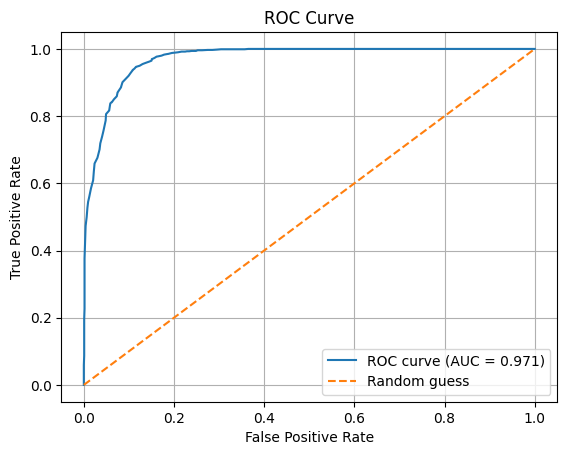

In [20]:
# Probabilities for positive class
y_proba = clf.predict_proba(X_test)[:, 1]

# Compute ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.grid()
plt.show()

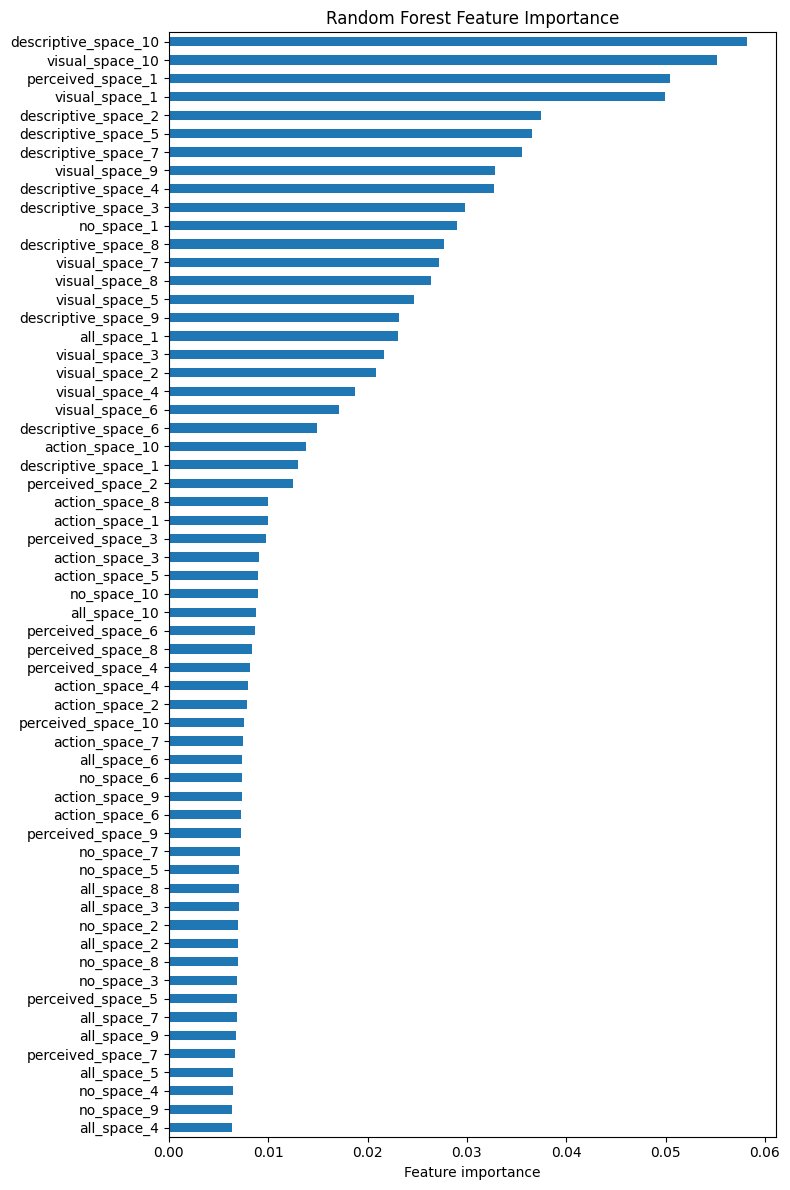

In [21]:
imp = pd.Series(clf.feature_importances_, index=X_test.columns)
imp = imp.sort_values(ascending=False)


plt.figure(figsize=(8, 12))  
imp.sort_values().plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [22]:
df.to_csv("./Ger_Dataset")

In [ ]:
import logging
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.FileHandler("run_ger.log", mode="w"), logging.StreamHandler()],
)
log = logging.info

random_seed = 127
key_to_labels = {
    "Human": 0, "GPT 4.1": 1, "Gemma": 2,
    "LLaMa 3.3 70B": 3, "Mistral": 4,
}
labels = list(key_to_labels.keys())

df_stat["target"] = df_stat["model"].map(key_to_labels)
X = df_stat.drop(columns=["target", "model"])
y = df_stat["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=random_seed
)

param_grid = {
    "n_estimators": [300, 500, 600, 700],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_leaf": [1, 2, 5],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
grid = GridSearchCV(
    RandomForestClassifier(random_state=random_seed),
    param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=2,
)
grid.fit(X_train, y_train)
clf = grid.best_estimator_
log(f"Best params: {grid.best_params_}")

cv_scores = cross_val_score(clf, X_train, y_train, cv=cv,
                            scoring="accuracy", n_jobs=-1)
log(f"CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

dummy = DummyClassifier(strategy="stratified", random_state=random_seed).fit(X_train, y_train)
log(f"Random baseline accuracy: {dummy.score(X_test, y_test):.3f}")

y_pred = clf.predict(X_test)
log(f"Test accuracy: {clf.score(X_test, y_test):.3f}")
log("\n" + classification_report(y_test, y_pred, target_names=labels, digits=3))

cm = confusion_matrix(y_test, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False
)
ax.set_title("Confusion matrix (row-normalized)")
plt.tight_layout()
plt.savefig("confusion_matrix_ger.pdf", bbox_inches="tight")
plt.show()